In [2]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
from plot import discover_runs, load_run_data, get_pynuc_eps

from scipy.interpolate import interp1d

plt.style.use("../ManuscriptFigures/utils/pub.mplstyle")

In [3]:
base_dir = "GF_Validation_Output"

In [4]:
def collect_species(steps, sp):
    abundances = []
    for step in steps:
        abundances.append(step["Composition"][sp])
    return np.array(abundances)

def collect_time(steps):
    times = []
    for step in steps:
        times.append(step["t"])
    return np.array(times)

In [38]:
runs = discover_runs(base_dir)

In [40]:
def plot_run_abundance(run_id, species=("H-1", "He-3", "He-4", "C-12", "N-14", "O-16")):
    fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True, gridspec_kw={'hspace': 0})
    data = load_run_data(base_dir, run_id)

    for spID, sp in enumerate(species):
        gf_t, gf_y = collect_time(data[0]["Steps"]), collect_species(data[0]["Steps"], sp)
        py_t, py_y = collect_time(data[1]["Steps"]), collect_species(data[1]["Steps"], sp)

        axs[0].loglog(gf_t, gf_y, color=f"C{spID}", label=f"GF {sp}")
        axs[0].loglog(py_t, py_y, color=f"C{spID}", linestyle="dashed")

        el = sp.split('-')[0]
        A = sp.split('-')[1]
        axs[0].text(gf_t[0], gf_y[0]*0.45, rf"$^{{{A}}}${el}", color=f"C{spID}", fontsize=12)

        f_pync = interp1d(py_t, py_y, fill_value="extrapolate", bounds_error=False)
        f_gf = interp1d(gf_t, gf_y, fill_value="extrapolate", bounds_error=False)

        t_common = np.logspace(np.log10(max(min(gf_t), min(py_t))), np.log10(min(max(gf_t), max(py_t))), 100)
        py_interp = f_pync(t_common)
        gf_interp = f_gf(t_common)

        log_diff = np.abs(np.log10(py_interp) - np.log10(gf_interp))

        axs[1].loglog(t_common, log_diff, color=f"C{spID}")
        # axs[1].set_xlim(t_common[0], 3.1e17)

    axs[0].set_ylabel("Abundance [mol/g]")
    axs[1].set_xlabel("Time [s]")
    axs[1].set_ylabel(r"$\left|\Delta\log_{10}\right|$ [dex]")

    return fig, axs


In [44]:
for run in runs:
    if "No_QSE" in run:
        fig, axs = plot_run_abundance(run);
        axs[0].set_ylim(1e-8)
        plt.savefig(f"{run}_abundance.pdf", bbox_inches='tight')
        plt.close()

/var/folders/v3/xfq17d692dg_gzdwv4yzmrkw0000gp/T/ipykernel_42214/2916075565.py:23: RuntimeWarning: divide by zero encountered in log10
  log_diff = np.abs(np.log10(py_interp) - np.log10(gf_interp))
/var/folders/v3/xfq17d692dg_gzdwv4yzmrkw0000gp/T/ipykernel_42214/2916075565.py:23: RuntimeWarning: invalid value encountered in log10
  log_diff = np.abs(np.log10(py_interp) - np.log10(gf_interp))


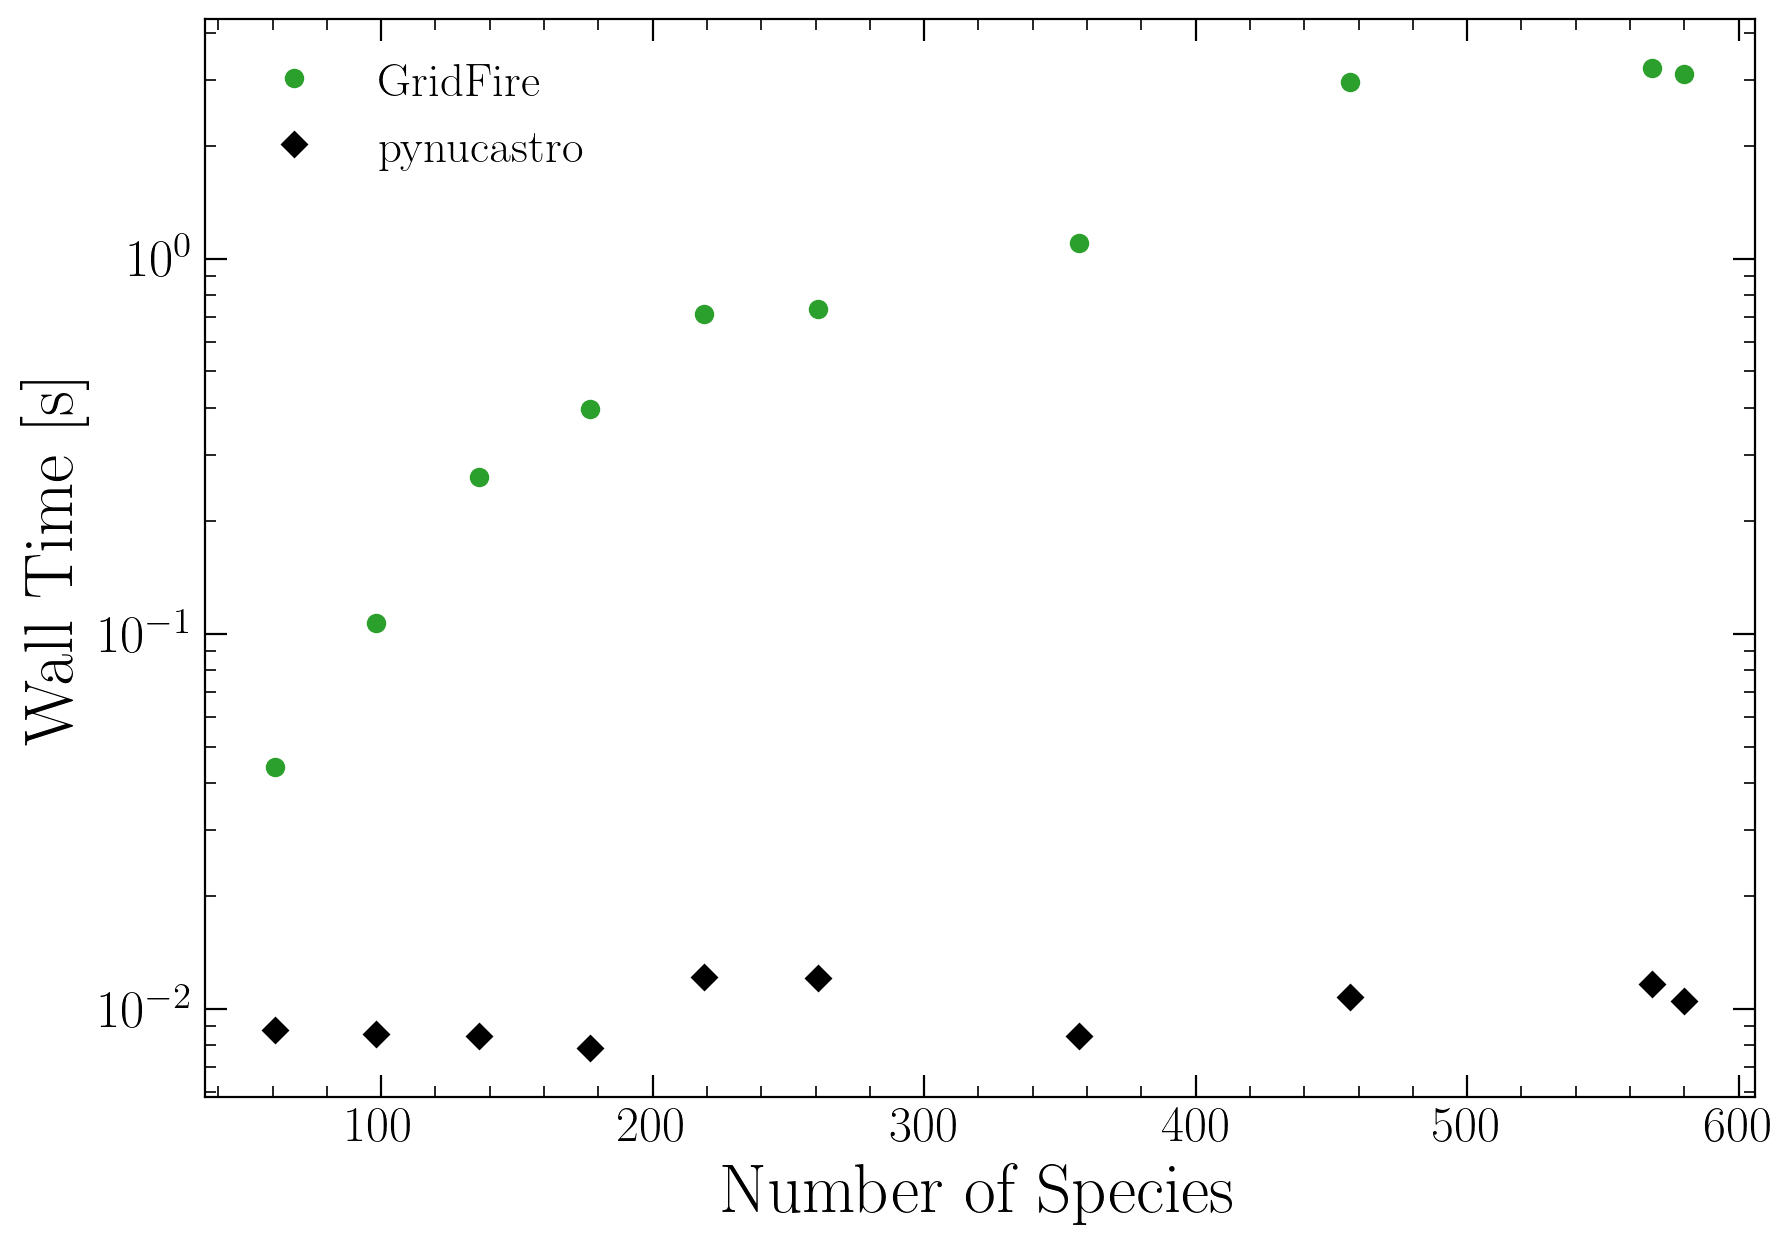

In [26]:
num_species = []
py_time = []
gf_time = []
for run in runs:
    if "Depth" in run:
        data = load_run_data(base_dir, run)
        num_species.append(data[0]["Metadata"]["NumSpecies"])
        gf_time.append(data[0]["Metadata"]["ElapsedTime"])
        py_time.append(data[1]["Metadata"]["RunTime1"])

fig, ax = plt.subplots(figsize=(10, 7))
ax.semilogy(num_species, gf_time, 'o', label='GridFire', color='C2')
ax.semilogy(num_species, py_time, 'D', label='pynucastro', color='black')

ax.legend(fontsize=17, frameon=False)
ax.set_xlabel("Number of Species", fontsize=25)
ax.set_ylabel("Wall Time [s]", fontsize=25)

plt.savefig("GF_PyNuc_WallTime.pdf", bbox_inches='tight')



In [27]:
for ns, t in zip(num_species, py_time):
    print(f"pynucastro: {ns} species, {t:.2e} seconds")

pynucastro: 357 species, 8.47e-03 seconds
pynucastro: 457 species, 1.07e-02 seconds
pynucastro: 568 species, 1.17e-02 seconds
pynucastro: 61 species, 8.80e-03 seconds
pynucastro: 580 species, 1.05e-02 seconds
pynucastro: 98 species, 8.55e-03 seconds
pynucastro: 136 species, 8.49e-03 seconds
pynucastro: 177 species, 7.85e-03 seconds
pynucastro: 219 species, 1.21e-02 seconds
pynucastro: 261 species, 1.21e-02 seconds
